# Smoothed: Brain age prediction model - Regression

This notebook trains a regression model for brain age prediction using smoothed asymmetry maps, where each image contains voxel-wise gray matter asymmetry information. The model is trained on healthy subjects from the Human Connectome Project (HCP: age range 22-35 years) and the Cambridge Centre for Ageing and Neuroscience (CamCAN: age range 18-89 years).

This notebook is identical to the "unsmoothed_model_training"-notebook, except for utilizing smoothed asymemtry maps instead of unsmoothed maps.

## Environment setup

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MMIV-ML/fastMONAI/blob/main/nbs/10b_tutorial_regression.ipynb)

In [1]:
# Install fastMONAI only when the notebook is executed in Google Colab
# When running locally, the existing local Python environment is used instead
try:
    import google.colab
    %pip install fastMONAI
    from fastMONAI.utils import print_colab_gpu_info
    print_colab_gpu_info()
except:
    print('Running locally')

Running locally


In [2]:
# Import libraries
from fastMONAI.vision_all import *
import numpy as np
import pandas as pd
import os
from pathlib import Path
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from fastai.callback.tracker import SaveModelCallback
from monai.networks.nets import Regressor
from fastai.callback.tracker import EarlyStoppingCallback
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

## Paths and dataset metadata

In [3]:
# Define the main data directory and the folder containing the smoothed asymmetry maps
data_dir =  Path('/home/anneaasengen/fastMONAI/data_asymmetry')
image_dir = data_dir / 'smoothed_asymmetry_images'

camcan_tsv = data_dir / 'participants_cc700.tsv'
hcp_csv    = data_dir / 'HCP_participants.csv'

In [4]:
# Load CamCAN metadata and keep only the variables needed for model training and inspection
df_camcan = pd.read_csv(camcan_tsv, sep="\t")
df_camcan['dataset'] = 'CamCAN'
df_camcan = df_camcan[['participant_id', 'p2_age', 'sex', 'dataset']]
df_camcan = df_camcan.rename(columns={'p2_age': 'age'})

In [5]:
df_camcan.head()

,participant_id,age,sex,dataset
0,sub-CC110033,24.7,M,CamCAN
1,sub-CC110037,18.8,M,CamCAN
2,sub-CC110045,24.9,F,CamCAN
3,sub-CC110056,22.7,F,CamCAN
4,sub-CC110062,20.2,M,CamCAN


In [6]:
len(df_camcan) # Number of CamCAN subjects

653

In [7]:
# Load HCP metadata and match column names with the CamCAN metadata

df_hcp = pd.read_csv(hcp_csv)
df_hcp = df_hcp.rename(columns={
    'Subject': 'subject_id',
    'Age_in_Yrs': 'age',
    'Gender': 'sex'
})

# Make participant_id match image filenames
df_hcp['participant_id'] = 'sub-' + df_hcp['subject_id'].astype(str)

df_hcp['dataset'] = 'HCP'

df_hcp = df_hcp[['participant_id', 'age', 'sex', 'dataset']]

In [8]:
df_hcp.head()

,participant_id,age,sex,dataset
0,sub-100004,24,M,HCP
1,sub-100206,27,M,HCP
2,sub-100307,27,F,HCP
3,sub-100408,33,M,HCP
4,sub-100610,27,M,HCP


## Build dataframe linking images to subject metadata

In [9]:
# Build one dataframe where each row links an asymmetry image to subject metadata
rows = []

for fname in sorted(os.listdir(image_dir)):
    # Only include NIfTI image files
    if not fname.endswith(".nii"):
        continue

    # Extract subject ID from the expected filename structure
    try:
        raw_id = fname.split("sAI_mwrp1sub-")[1].split("_")[0]
    except IndexError:
        print("Filename does not match expected format:", fname)
        continue

    
    participant_id = "sub-" + raw_id

    # Try to match the image to CamCAN metadata first
    match = df_camcan[df_camcan["participant_id"] == participant_id]

    # If there is no CamCAN match, try matching against HCP metadata
    if len(match) == 0:
        match = df_hcp[df_hcp["participant_id"] == participant_id]

    # Store image path and metadata when exactly one subject match is found
    if len(match) == 1:
        rows.append({
            "image_path": str(image_dir / fname),
            "participant_id": participant_id,
            "age": float(match["age"].values[0]),
            "sex": match["sex"].values[0],
            "dataset": match["dataset"].values[0]
        })
    else:
        print("No metadata match for:", participant_id)

# Final dataframe used for training, validation and testing
df = pd.DataFrame(rows)

## Remove subjects with missing age

In [10]:
# Remove subjects without age information, since chronological age is the regression target
print("Total subjects before NaN removal:", len(df))
df = df.dropna(subset=["age"]).reset_index(drop=True)
print("After NaN removal:", len(df))

# Ensure that age is stored as a numerical variable
df['age'] = df['age'].astype(float)

Total subjects before NaN removal: 903
After NaN removal: 902


In [11]:
df.head()

,image_path,participant_id,age,sex,dataset
0,/home/anneaasengen/fastMONAI/data_asymmetry/smoothed_asymmetry_images/sAI_mwrp1sub-144428_T1w_affine.nii,sub-144428,25.0,M,HCP
1,/home/anneaasengen/fastMONAI/data_asymmetry/smoothed_asymmetry_images/sAI_mwrp1sub-154532_T1w_affine.nii,sub-154532,28.0,M,HCP
2,/home/anneaasengen/fastMONAI/data_asymmetry/smoothed_asymmetry_images/sAI_mwrp1sub-158136_T1w_affine.nii,sub-158136,33.0,M,HCP
3,/home/anneaasengen/fastMONAI/data_asymmetry/smoothed_asymmetry_images/sAI_mwrp1sub-165032_T1w_affine.nii,sub-165032,24.0,M,HCP
4,/home/anneaasengen/fastMONAI/data_asymmetry/smoothed_asymmetry_images/sAI_mwrp1sub-165234_T1w_affine.nii,sub-165234,23.0,F,HCP


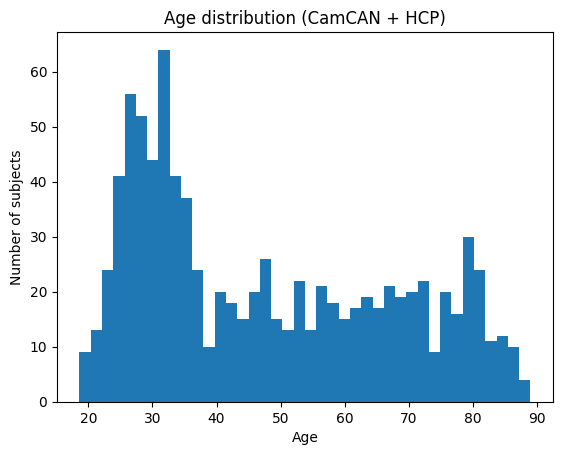

In [13]:
# Visualize the age distribution of the combined healthy dataset

plt.hist(df["age"], bins=40)
plt.xlabel("Age")
plt.ylabel("Number of subjects")
plt.title("Age distribution (CamCAN + HCP)")
plt.show()

## Train / validation / test split

In [14]:
# Split subjects into training, validation and test sets
# 70% training, 15% validation and 15% test data
idx = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    idx, test_size=0.3, random_state=123
)

valid_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=123
)

In [15]:
# Save split indices so the same train/validation/test split can be reused later
np.save("smoothed_train_idx.npy", train_idx)
np.save("smoothed_valid_idx.npy", valid_idx)
np.save("smoothed_test_idx.npy", test_idx)

In [16]:
# fastai splitter function defining which rows are used for training and validation
def splitter(o):
    return train_idx, valid_idx

In [17]:
# Check how many subjects from each dataset are included in each split
def dataset_counts(indices, name):
    print(f"\n{name}")
    print(df.iloc[indices]["dataset"].value_counts())

dataset_counts(train_idx, "TRAIN")
dataset_counts(valid_idx, "VALID")
dataset_counts(test_idx,  "TEST")


TRAIN
dataset
CamCAN    456
HCP       175
Name: count, dtype: int64

VALID
dataset
CamCAN    99
HCP       36
Name: count, dtype: int64

TEST
dataset
CamCAN    96
HCP       40
Name: count, dtype: int64


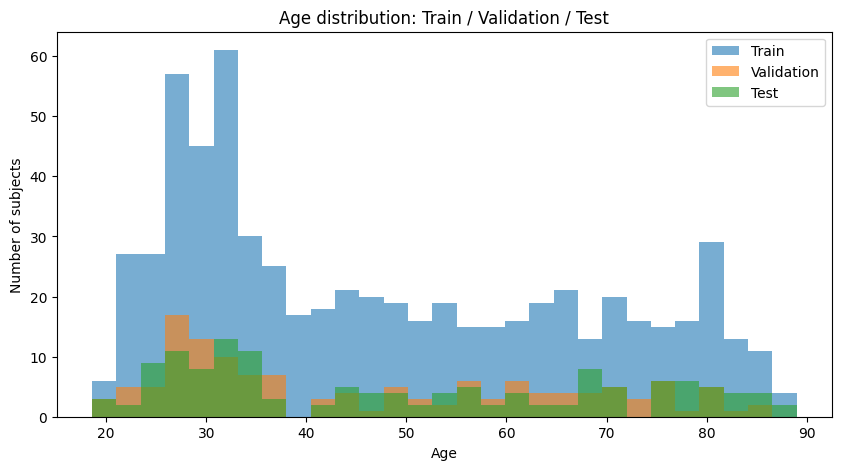

In [18]:
# Extract chronological ages for each data split
age_train = df.iloc[train_idx]["age"]
age_valid = df.iloc[valid_idx]["age"]
age_test  = df.iloc[test_idx]["age"]

# Plot overlapping age histograms to inspect whether the splits have comparable age distributions
plt.figure(figsize=(10, 5))

bins = np.linspace(df["age"].min(), df["age"].max(), 30)

plt.hist(age_train, bins=bins, alpha=0.6, label="Train")
plt.hist(age_valid, bins=bins, alpha=0.6, label="Validation")
plt.hist(age_test,  bins=bins, alpha=0.6, label="Test")

plt.xlabel("Age")
plt.ylabel("Number of subjects")
plt.title("Age distribution: Train / Validation / Test")
plt.legend()
plt.show()

## Dataset inspection 

In [19]:
# Image shape
# Load one example image to inspect the 3D image dimensions
img = nib.load(df.image_path.iloc[0])
img.shape

(113, 137, 113)

In [21]:
# Number of subjects and variables in the dataframe
df.shape

(902, 5)

In [22]:
# Age range in the dataset: max and min age
df.age.min(), df.age.max()

(np.float64(18.6), np.float64(89.0))

## fastMONAI dataset utilities

In [23]:
# Create a fastMONAI MedDataset object from the folder containing the NIfTI images
med_dataset = MedDataset(path=image_dir, max_workers=12)

In [24]:
# Summarize image properties such as dimensions, spacing and orientation
data_info_df = med_dataset.summary()

In [25]:
data_info_df.head()

,dim_0,dim_1,dim_2,voxel_0,voxel_1,voxel_2,orientation,example_path,total
0,113,137,113,1.5,1.5,1.5,LAS+,/home/anneaasengen/fastMONAI/data_asymmetry/smoothed_asymmetry_images/sAI_mwrp1sub-144428_T1w_affine.nii,903


In [26]:
# Obtain suggested preprocessing settings to make image orientation and spacing consistent
resample, reorder = med_dataset.suggestion()

In [27]:
import pickle

# Save preprocessing parameters so the same settings can be used later
save_path = Path("/home/anneaasengen/fastMONAI/nbs/smoothed_preproc_params.pkl")

with open(save_path, "wb") as f:
    pickle.dump(
        {
            "resample": resample,
            "reorder": reorder
        },
        f
    )

print("Saved preprocessing parameters to:", save_path)

Saved preprocessing parameters to: /home/anneaasengen/fastMONAI/nbs/smoothed_preproc_params.pkl


## DataBlock and DataLoaders

In [28]:
# Define training batch size and the fixed input shape expected by the 3D CNN
bs=4
in_shape = [1, 128, 160, 128]

In [29]:
# Define image transformations applied during loading
# Z-normalization standardizes image intensity, PadOrCrop gives all images the same shape,
# and RandomAffine applies small augmentations during training
item_tfms = [ZNormalization(), 
             PadOrCrop(in_shape[1:]), 
             RandomAffine(scales=(0.97, 1.03), degrees=3, isotropic=False)] 

In [30]:
# Define the fastMONAI DataBlock used for 3D image regression
# The model input is the asymmetry map, and the regression target is chronological age
dblock = MedDataBlock(blocks=(ImageBlock(cls=MedImage), RegressionBlock), 
                      splitter=splitter,
                      get_x=ColReader('image_path'),
                      get_y=ColReader('age'),
                      item_tfms=item_tfms,
                      reorder=reorder,
                      resample=resample) 

In [31]:
# Create DataLoaders for training and validation
dls = dblock.dataloaders(df, bs=bs)

In [32]:
len(dls.train_ds.items), len(dls.valid_ds.items)

(631, 135)

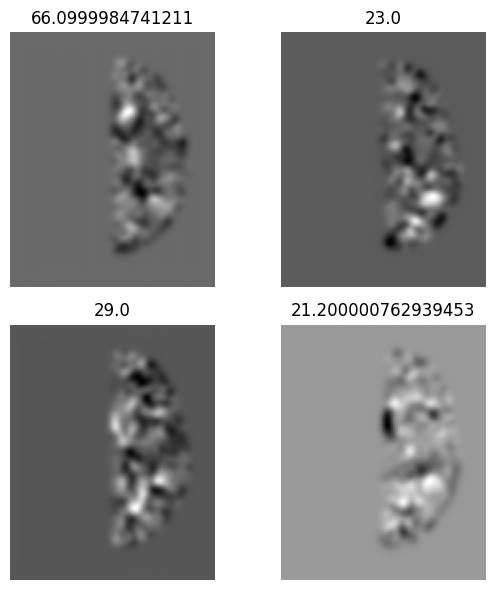

In [33]:
# Visualize a batch of asymmetry maps to check that loading and transformations work as expected
dls.show_batch(anatomical_plane=2)

## Model definition

In [34]:
# Define the 3D CNN regression model
# The network outputs one continuous value: predicted brain age
model = Regressor(
    in_shape=in_shape,
    out_shape=1,
    channels=(64, 128, 256, 256, 256),
    strides=(2, 2, 2, 2),
    kernel_size=3,
    num_res_units=2)

## Training setup

In [35]:
# Save the model checkpoint with the lowest validation MAE during training
cbs = [SaveModelCallback(
        monitor='mae',
        comp=np.less,
        fname='smoothed_baseline_best')]

In [36]:
# Use L1 loss because age prediction is evaluated using absolute error
loss_func = L1LossFlat()

# Create the fastai Learner with MAE as evaluation metric and weight decay for regularization
learn = Learner(
    dls,
    model,
    loss_func=loss_func,
    metrics=[mae],
    wd=1e-2)

In [37]:
learn.summary()

Regressor (Input shape: 4 x 1 x 128 x 160 x 128)
Layer (type)         Output Shape         Param #    Trainable 
                     4 x 64 x 64 x 80 x  
Conv3d                                    1792       True      
InstanceNorm3d                            0          False     
PReLU                                     1          True      
Conv3d                                    110656     True      
InstanceNorm3d                            0          False     
PReLU                                     1          True      
Conv3d                                    1792       True      
____________________________________________________________________________
                     4 x 128 x 32 x 40 x 
Conv3d                                    221312     True      
InstanceNorm3d                            0          False     
PReLU                                     1          True      
Conv3d                                    442496     True      
InstanceNorm3d        

SuggestedLRs(valley=7.585775892948732e-05)

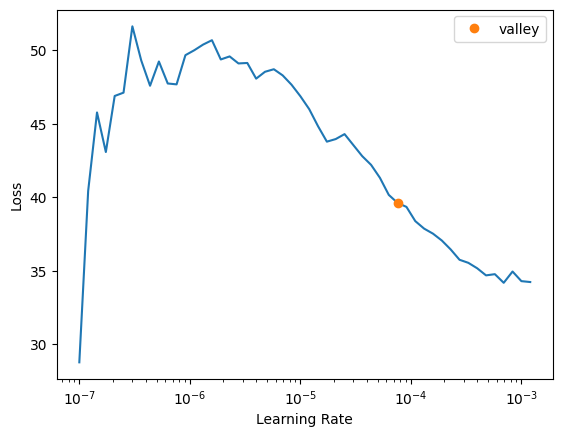

In [38]:
# Estimate a suitable learning rate before training
learn.lr_find()

In [39]:
# The selected learning rate for model training
lr = 1e-4

In [40]:
# Print key training settings 
print("Model:", model)
print("Batch size:", bs)
print("LR:", lr)
print("Epochs: 400")
print("N subjects:", len(df))

Model: Regressor(
  (net): Sequential(
    (layer_0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (layer_1): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
  

In [41]:
# Train the model for 400 epochs using the one-cycle learning rate policy
learn.fit_one_cycle(400, lr, cbs=cbs) 

epoch,train_loss,valid_loss,mae,time
0,17.671053,15.805129,15.805129,01:40
1,14.305138,13.942862,13.942862,01:40
2,12.897684,11.835806,11.835806,01:42
3,10.756629,11.212151,11.212151,01:40
4,9.828721,10.170674,10.170674,01:41
5,8.265072,10.403068,10.403068,01:40
6,7.628707,9.316508,9.316508,01:41
7,6.407458,8.999449,8.999449,01:40
8,6.021825,9.246217,9.246217,01:40
9,5.322365,8.908692,8.908692,01:39


Better model found at epoch 0 with mae value: 15.805129051208496.
Better model found at epoch 1 with mae value: 13.942861557006836.
Better model found at epoch 2 with mae value: 11.835805892944336.
Better model found at epoch 3 with mae value: 11.212150573730469.
Better model found at epoch 4 with mae value: 10.170674324035645.
Better model found at epoch 6 with mae value: 9.316508293151855.
Better model found at epoch 7 with mae value: 8.999448776245117.
Better model found at epoch 9 with mae value: 8.908692359924316.
Better model found at epoch 10 with mae value: 8.401117324829102.
Better model found at epoch 11 with mae value: 8.318817138671875.
Better model found at epoch 12 with mae value: 7.96593713760376.
Better model found at epoch 18 with mae value: 7.850113868713379.
Better model found at epoch 29 with mae value: 7.830332279205322.
Better model found at epoch 39 with mae value: 7.533594131469727.
Better model found at epoch 89 with mae value: 7.428528308868408.
Better model f

In [42]:
# Load the model checkpoint with the best validation MAE
learn.load('smoothed_baseline_best'); 

Saved file doesn't contain an optimizer state.


In [43]:
# Generate predictions for the validation set and compute validation MAE
preds_val, targs_val = learn.get_preds(dl=dls.valid)

preds_val = preds_val.squeeze().cpu().numpy()
targs_val = targs_val.squeeze().cpu().numpy()

error_val = preds_val - targs_val

print("Validation MAE:", np.mean(np.abs(error_val)))

Validation MAE: 6.8478274


## Test set evaluation (MAE)

In [44]:
# Create a separate test DataLoader from the test set
test_dl = dls.test_dl(df.iloc[test_idx], with_labels=True)

In [45]:
# Predict brain age for the test subjects
preds_test, targs_test = learn.get_preds(dl=test_dl)

In [46]:
# Convert predictions and targets from tensors to NumPy arrays
preds_test = preds_test.squeeze().cpu().numpy()
targs_test = targs_test.squeeze().cpu().numpy()

In [47]:
# Compute raw prediction error and test MAE
error_raw = preds_test - targs_test
test_mae = np.mean(np.abs(error_raw))
print("Test-MAE:", test_mae)

Test-MAE: 6.460948


## Bias analysis on train set

In [48]:
# Bias analysis on train set
# Evaluate performance on the training set to inspect training error and possible prediction bias
preds_train, targs_train = learn.get_preds(dl=dls.train)

preds_train = preds_train.squeeze().cpu().numpy()
targs_train = targs_train.squeeze().cpu().numpy()

error_train = preds_train - targs_train

print("Train MAE:", np.mean(np.abs(error_train)))
print("Train mean error (bias):", np.mean(error_train)) # number of years the model overestimates (mean)
print("Train corr(pred, true):", np.corrcoef(preds_train, targs_train)[0,1]) # Pearson correlation: checks for linear correlation, 1=linear, 0= non linear

Train MAE: 1.3266914
Train mean error (bias): -0.48639834
Train corr(pred, true): 0.9968011370298376


## Bias correction (linear) (estimated on train, applied to test)

In [49]:
# Linear bias correction
# Estimate bias-correction parameters from the training set only
# The fitted relation is: predicted age = a * chronological age + b
a, b = np.polyfit(targs_train, preds_train, 1)

a, b

(np.float64(1.0151518314488375), np.float64(-1.2086172457368776))

In [50]:
# Save the linear bias-correction parameters for later use
np.save("smoothed_bias_correction_params.npy", np.array([a, b]))

In [51]:
# Apply inverse linear bias correction to the test predictions
preds_test_bc = (preds_test - b) / a

In [52]:
# Compare test MAE before and after linear bias correction
test_mae_raw = test_mae #rename
error_bc = preds_test_bc - targs_test
test_mae_bc = np.mean(np.abs(error_bc))

test_mae_raw, test_mae_bc # test MAE with and without the bias correction on the prediction values
print(f"Test MAE (raw): {test_mae_raw:.7f}")
print(f"Test MAE (bias-corrected): {test_mae_bc:.7f}")

Test MAE (raw): 6.4609480
Test MAE (bias-corrected): 6.4365177


## Testing of non-linear bias correction

In [53]:
# Test a quadratic bias-correction approach as an alternative to linear correction
targs_train = np.array(targs_train)
preds_train = np.array(preds_train)

# Brain age gap (BAG) on the training set
BAG_train = preds_train - targs_train

# Create quadratic age features: age and age^2
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(targs_train.reshape(-1, 1))

# Fit a linear regression model to estimate age-related BAG bias from the quadratic features
bias_model = LinearRegression()
bias_model.fit(X_train_poly, BAG_train)

print("Bias coefficients:", bias_model.coef_)
print("Intercept:", bias_model.intercept_)

Bias coefficients: [0.         0.00051883 0.0001406 ]
Intercept: -0.88451725


In [54]:
# Function for applying the quadratic bias correction to a set of predictions
def apply_quadratic_bias_correction(y_true, y_pred, poly, bias_model):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Compute uncorrected brain age gap
    BAG = y_pred - y_true

    # Estimate the age-related bias using the fitted quadratic model
    X_poly = poly.transform(y_true.reshape(-1, 1))
    estimated_bias = bias_model.predict(X_poly)

    # Remove estimated bias from BAG, then reconstruct corrected predicted age
    BAG_corrected = BAG - estimated_bias
    
    y_pred_corrected = y_true + BAG_corrected
    
    return y_pred_corrected


In [55]:
# Apply quadratic bias correction to both training and test predictions
y_pred_train_corr = apply_quadratic_bias_correction(
    targs_train, preds_train, poly, bias_model
)

# Corrects test
y_pred_test_corr = apply_quadratic_bias_correction(
    targs_test, preds_test, poly, bias_model
)


In [56]:
# Compare the correlation between BAG and chronological age before and after quadratic correction
# Before correction
BAG_test = preds_test - targs_test
r_before, _ = pearsonr(BAG_test, targs_test)

# After correction
BAG_test_corr = y_pred_test_corr - targs_test
r_after, _ = pearsonr(BAG_test_corr, targs_test)

print("Correlation before correction:", r_before)
print("Correlation after non-linear correction:", r_after)

Correlation before correction: -0.51696527
Correlation after non-linear correction: -0.5455381


In [57]:
# Compare MAE for raw, linear bias-corrected and quadratic bias-corrected predictions
mae_before = mean_absolute_error(targs_test, preds_test)
mae_after = mean_absolute_error(targs_test, y_pred_test_corr)

print(f"Test MAE before correction (raw): {mae_before:.7f}")
print(f"Test MAE (linear bias-corrected): {test_mae_bc:.7f}")
print(f"Test MAE (non-linear bias-corrected): {mae_after:.7f}")

Test MAE before correction (raw): 6.4609480
Test MAE (linear bias-corrected): 6.4365177
Test MAE (non-linear bias-corrected): 6.5360150


Conclusion: No improvement with non-linear bias correction. Therefore, only linear bias correction will be used further. From now, bias correction refers to linear bias correction.

## Plot: True age vs Prediction error (test set)

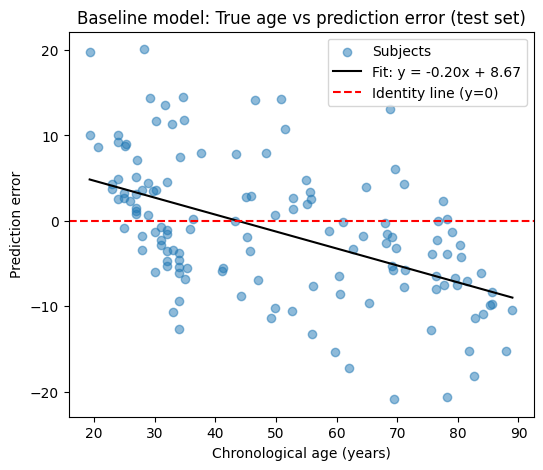

In [61]:
# Plot raw prediction error as a function of chronological age
coef = np.polyfit(targs_test, error_raw, 1)
x_line = np.linspace(targs_test.min(), targs_test.max(), 100) 
y_line = coef[0] * x_line + coef[1]

plt.figure(figsize=(6, 5))
plt.scatter(targs_test, error_raw, alpha=0.5, label="Subjects")
plt.plot(x_line, y_line, color='black', label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}")
plt.axhline(0, color='red', linestyle='--', label="Identity line (y=0)") # Identity line: Perfect prediction

plt.xlabel("Chronological age (years)")
plt.ylabel("Prediction error")
plt.title("Baseline model: True age vs prediction error (test set)")
plt.legend()
plt.show() 

## Plot: True age vs Bias-corrected prediction error (test set)

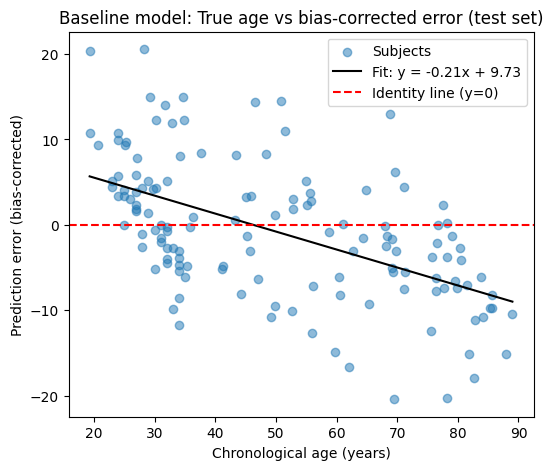

In [62]:
# Plot bias-corrected prediction error as a function of chronological age
coef_bc = np.polyfit(targs_test, error_bc, 1)
y_line_bc = coef_bc[0] * x_line + coef_bc[1]

plt.figure(figsize=(6, 5))
plt.scatter(targs_test, error_bc, alpha=0.5, label="Subjects")
plt.plot(x_line, y_line_bc, color='black', label=f"Fit: y = {coef_bc[0]:.2f}x + {coef_bc[1]:.2f}")

plt.axhline(0, color='red', linestyle='--', label="Identity line (y=0)")

plt.xlabel("Chronological age (years)")
plt.ylabel("Prediction error (bias-corrected)")
plt.title("Baseline model: True age vs bias-corrected error (test set)")
plt.legend()
plt.show()

## Quality Control (QC): Error-driven inspection of asymmetry images

In [63]:
# Build a QC dataframe containing test-set predictions and prediction errors
qc_df = df.iloc[test_idx].copy().reset_index(drop=True)
qc_df["predicted_age"] = preds_test
qc_df["predicted_age_bc"] = preds_test_bc

# Raw prediction error
qc_df["error_raw"] = qc_df["predicted_age"] - qc_df["age"]
qc_df["abs_error_raw"] = np.abs(qc_df["error_raw"])

# Bias-corrected prediction error
qc_df["error_bc"] = qc_df["predicted_age_bc"] - qc_df["age"]
qc_df["abs_error_bc"] = np.abs(qc_df["error_bc"])


qc_df.head()

,image_path,participant_id,age,sex,dataset,predicted_age,predicted_age_bc,error_raw,abs_error_raw,error_bc,abs_error_bc
0,/home/anneaasengen/fastMONAI/data_asymmetry/smoothed_asymmetry_images/sAI_mwrp1sub-211720_T1w_affine.nii,sub-211720,32.0,M,HCP,36.518345,37.163862,4.518345,4.518345,5.163862,5.163862
1,/home/anneaasengen/fastMONAI/data_asymmetry/smoothed_asymmetry_images/sAI_mwrp1sub-CC420462_T1w_affine.nii,sub-CC420462,55.7,F,CamCAN,59.114250,59.422508,3.414250,3.414250,3.722508,3.722508
2,/home/anneaasengen/fastMONAI/data_asymmetry/smoothed_asymmetry_images/sAI_mwrp1sub-CC520287_T1w_affine.nii,sub-CC520287,60.4,F,CamCAN,53.930874,54.316497,-6.469126,6.469126,-6.083503,6.083503
3,/home/anneaasengen/fastMONAI/data_asymmetry/smoothed_asymmetry_images/sAI_mwrp1sub-CC310361_T1w_affine.nii,sub-CC310361,43.5,F,CamCAN,51.279259,51.704459,7.779259,7.779259,8.204459,8.204459
4,/home/anneaasengen/fastMONAI/data_asymmetry/smoothed_asymmetry_images/sAI_mwrp1sub-CC520002_T1w_affine.nii,sub-CC520002,64.8,F,CamCAN,68.738945,68.903547,3.938945,3.938945,4.103547,4.103547


In [64]:
# Top 10 best and worst predictions based on absolute bias-corrected error
best_cases_bc = qc_df.sort_values("abs_error_bc").head(10)
worst_cases_bc = qc_df.sort_values("abs_error_bc", ascending=False).head(10)

In [65]:
best_cases_bc[
    ["participant_id", "sex", "age", "dataset", "predicted_age", "predicted_age_bc", "error_raw", "error_bc"]
]

,participant_id,sex,age,dataset,predicted_age,predicted_age_bc,error_raw,error_bc
23,sub-CC620413,M,76.7,CamCAN,76.658600,76.704996,-0.041400,0.004996
74,sub-204016,F,25.0,HCP,24.182337,25.011977,-0.817663,0.011977
81,sub-207628,M,31.0,HCP,30.232330,30.971670,-0.767670,-0.028330
73,sub-CC520980,M,68.0,CamCAN,67.736168,67.915737,-0.263832,-0.084263
24,sub-CC520065,M,61.1,CamCAN,60.968578,61.249159,-0.131422,0.149159
98,sub-CC620919,M,78.2,CamCAN,78.439636,78.459449,0.239636,0.259449
91,sub-CC221740,F,35.9,CamCAN,34.958900,35.627693,-0.941100,-0.272307
79,sub-172938,F,32.0,HCP,30.959114,31.687606,-1.040886,-0.312394
102,sub-CC320904,M,43.2,CamCAN,43.227745,43.773119,0.027745,0.573119
86,sub-189652,M,30.0,HCP,28.656460,29.419320,-1.343540,-0.580680


In [66]:
worst_cases_bc[
    ["participant_id", "sex", "age", "dataset", "predicted_age", "predicted_age_bc", "error_raw", "error_bc"]
]

,participant_id,sex,age,dataset,predicted_age,predicted_age_bc,error_raw,error_bc
131,sub-CC120049,M,28.3,CamCAN,48.395893,48.864129,20.095893,20.564129
43,sub-CC620479,M,69.4,CamCAN,48.503250,48.969884,-20.896750,-20.430116
29,sub-CC120061,M,19.3,CamCAN,39.075680,39.683026,19.775680,20.383026
130,sub-CC620279,M,78.3,CamCAN,57.637608,57.967905,-20.662392,-20.332095
65,sub-CC720071,M,82.7,CamCAN,64.558601,64.785598,-18.141399,-17.914402
50,sub-CC510433,F,62.1,CamCAN,44.899258,45.419684,-17.200742,-16.680316
72,sub-CC721224,F,88.0,CamCAN,72.730392,72.835420,-15.269608,-15.164580
8,sub-CC720685,M,81.8,CamCAN,66.524178,66.721837,-15.275822,-15.078163
16,sub-CC221980,M,34.7,CamCAN,49.256073,49.711470,14.556073,15.011470
110,sub-CC112141,M,29.2,CamCAN,43.581688,44.121779,14.381688,14.921779


In [67]:
# Top 10 best and worst predictions based on absolute raw error
best_cases = qc_df.sort_values("abs_error_raw").head(10)
worst_cases = qc_df.sort_values("abs_error_raw", ascending=False).head(10)

In [68]:
best_cases[
    ["participant_id", "sex", "age", "dataset", "predicted_age", "predicted_age_bc", "error_raw", "error_bc"]
]

,participant_id,sex,age,dataset,predicted_age,predicted_age_bc,error_raw,error_bc
102,sub-CC320904,M,43.2,CamCAN,43.227745,43.773119,0.027745,0.573119
23,sub-CC620413,M,76.7,CamCAN,76.658600,76.704996,-0.041400,0.004996
24,sub-CC520065,M,61.1,CamCAN,60.968578,61.249159,-0.131422,0.149159
98,sub-CC620919,M,78.2,CamCAN,78.439636,78.459449,0.239636,0.259449
62,sub-CC210088,F,36.3,CamCAN,36.548695,37.193758,0.248695,0.893758
73,sub-CC520980,M,68.0,CamCAN,67.736168,67.915737,-0.263832,-0.084263
123,sub-CC420004,F,49.9,CamCAN,50.564564,51.000431,0.664564,1.100431
109,sub-274542,F,29.0,HCP,29.683725,30.431253,0.683725,1.431253
81,sub-207628,M,31.0,HCP,30.232330,30.971670,-0.767670,-0.028330
59,sub-194645,M,27.0,HCP,27.798862,28.574523,0.798862,1.574523


In [69]:
worst_cases[
    ["participant_id", "sex", "age", "dataset", "predicted_age", "predicted_age_bc", "error_raw", "error_bc"]
]

,participant_id,sex,age,dataset,predicted_age,predicted_age_bc,error_raw,error_bc
43,sub-CC620479,M,69.4,CamCAN,48.503250,48.969884,-20.896750,-20.430116
130,sub-CC620279,M,78.3,CamCAN,57.637608,57.967905,-20.662392,-20.332095
131,sub-CC120049,M,28.3,CamCAN,48.395893,48.864129,20.095893,20.564129
29,sub-CC120061,M,19.3,CamCAN,39.075680,39.683026,19.775680,20.383026
65,sub-CC720071,M,82.7,CamCAN,64.558601,64.785598,-18.141399,-17.914402
50,sub-CC510433,F,62.1,CamCAN,44.899258,45.419684,-17.200742,-16.680316
64,sub-CC520197,F,59.7,CamCAN,44.287907,44.817457,-15.412093,-14.882543
8,sub-CC720685,M,81.8,CamCAN,66.524178,66.721837,-15.275822,-15.078163
72,sub-CC721224,F,88.0,CamCAN,72.730392,72.835420,-15.269608,-15.164580
16,sub-CC221980,M,34.7,CamCAN,49.256073,49.711470,14.556073,15.011470


In [70]:
# Helper function for visualizing one axial slice from an asymmetry map
def show_asymmetry_image(image_path, title=None, slice_idx=None):
    img = nib.load(image_path).get_fdata()

    # Default: mid axial slice is shown
    if slice_idx is None:
        slice_idx = img.shape[2] // 2

    plt.figure(figsize=(4, 4))
    plt.imshow(img[:, :, slice_idx].T, cmap="bwr", origin="lower")
    plt.colorbar(fraction=0.046)
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()


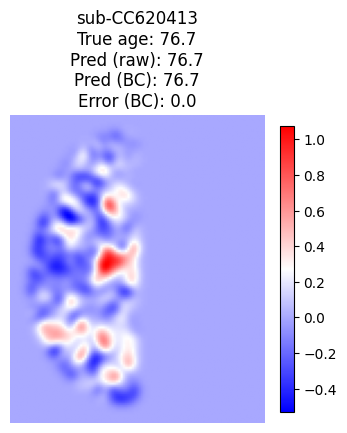

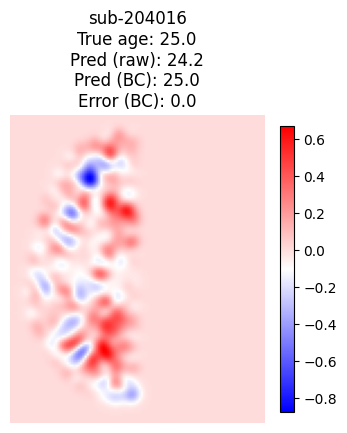

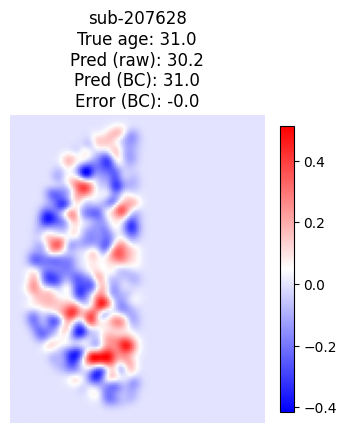

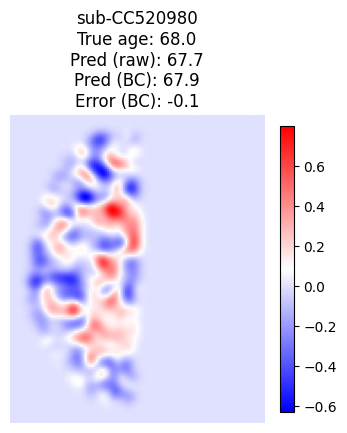

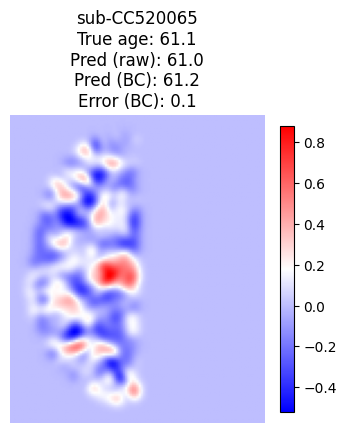

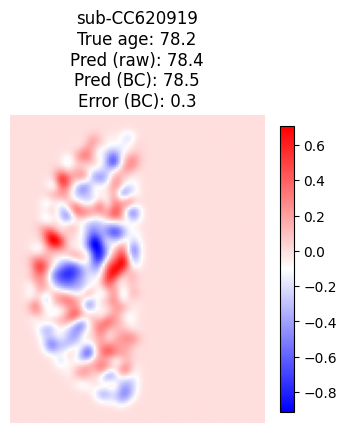

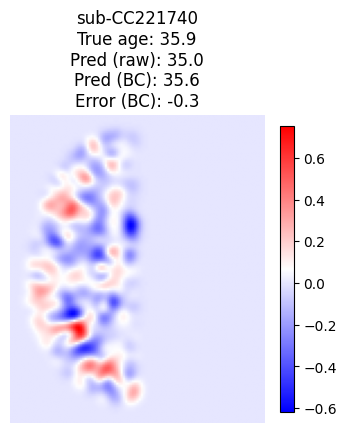

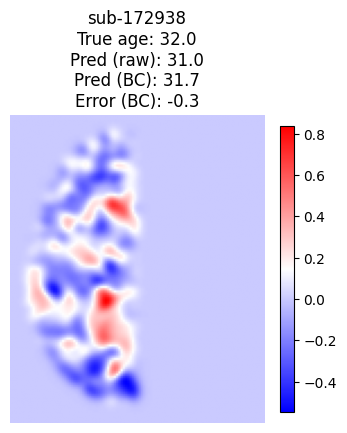

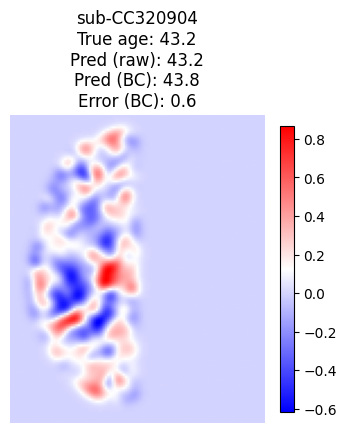

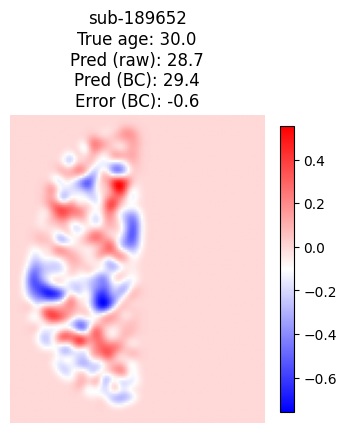

In [71]:
# Best cases sorted after bias-corrected predictions
for _, row in best_cases_bc.iterrows():
    title = (
    f"{row['participant_id']}\n"
    f"True age: {row['age']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"Error (BC): {row['error_bc']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

# In this color map, red/positive values indicate rightward asymmetry,
# while blue/negative values indicate leftward asymmetry

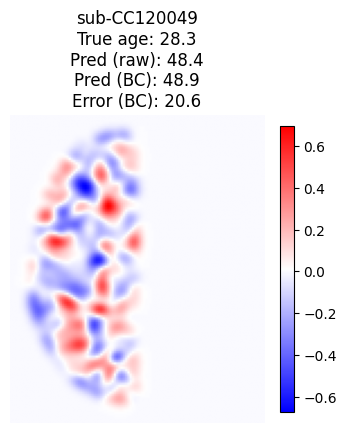

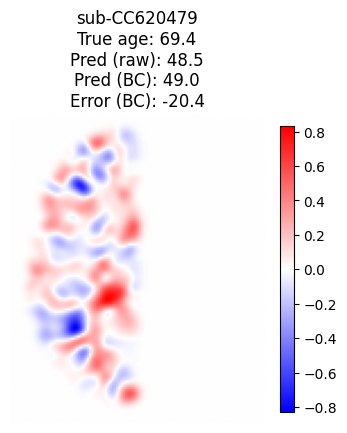

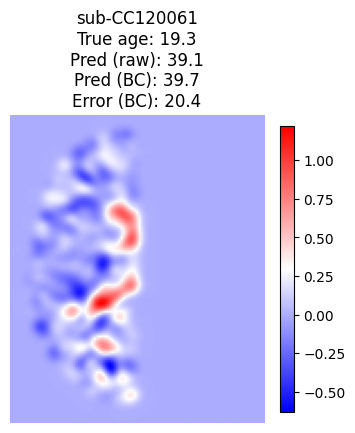

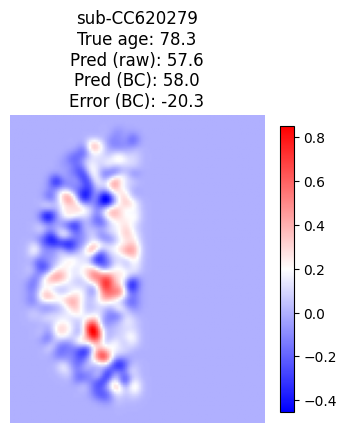

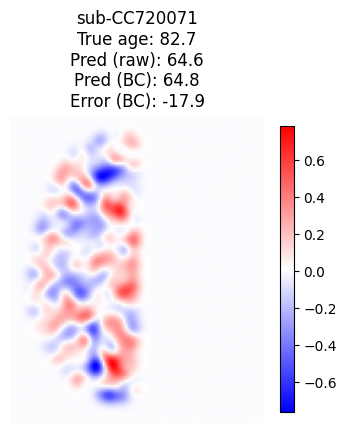

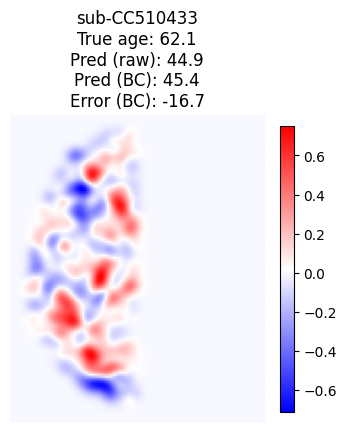

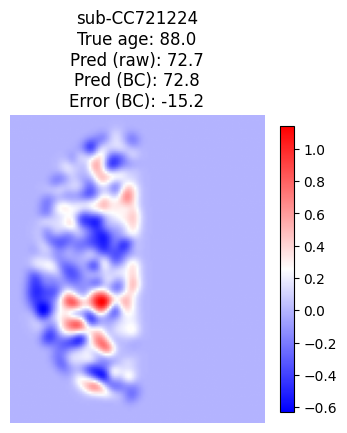

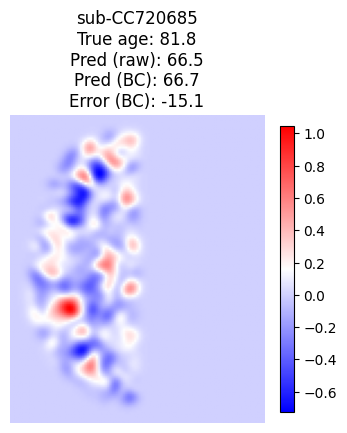

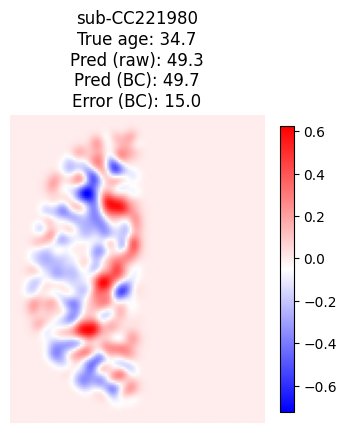

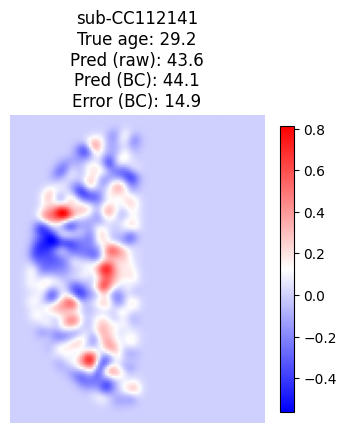

In [72]:
# Worst cases sorted after bias-corrected predictions
for _, row in worst_cases_bc.iterrows():
    title = (
    f"{row['participant_id']}\n"
    f"True age: {row['age']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"Error (BC): {row['error_bc']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)


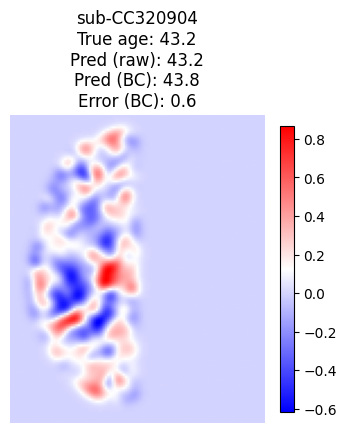

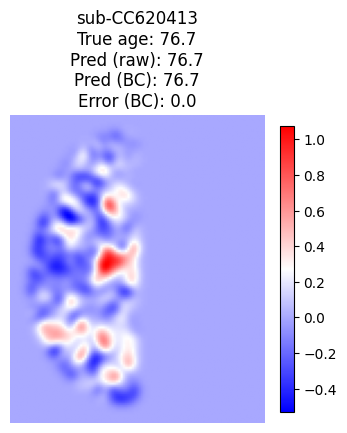

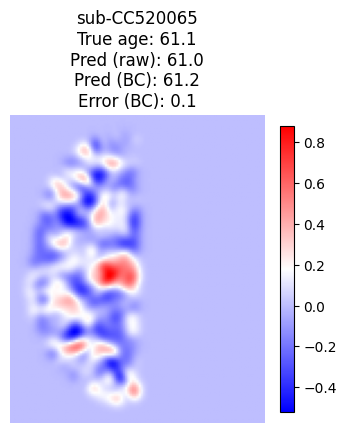

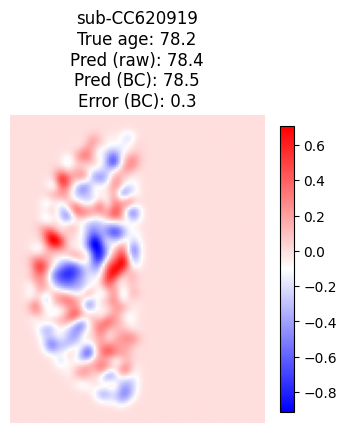

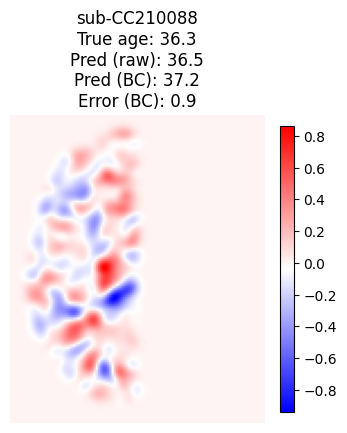

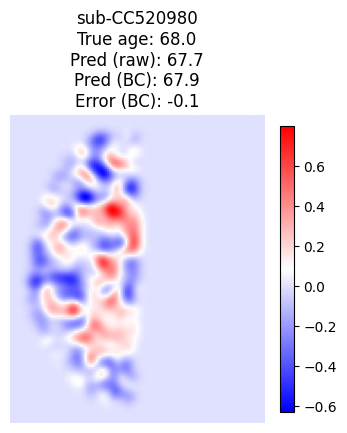

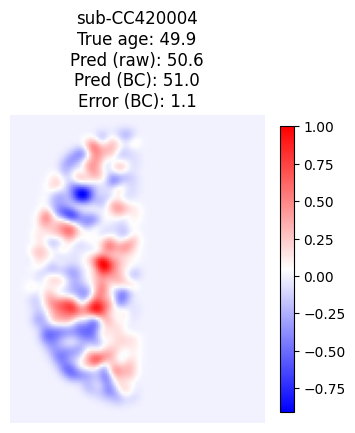

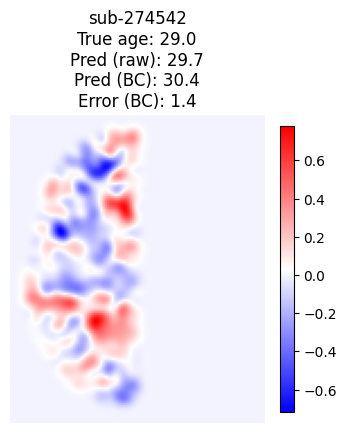

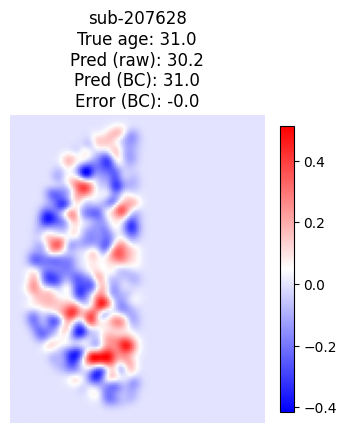

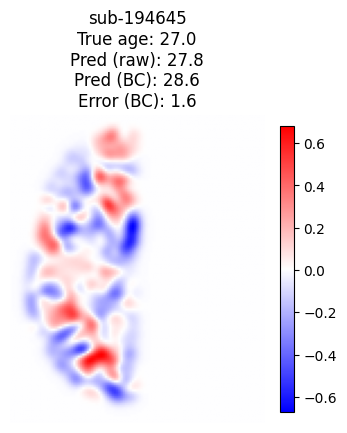

In [73]:
# Best cases sorted after raw predictions
for _, row in best_cases.iterrows():
    title = (
    f"{row['participant_id']}\n"
    f"True age: {row['age']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"Error (BC): {row['error_bc']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

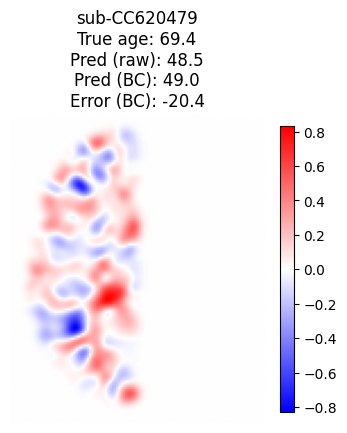

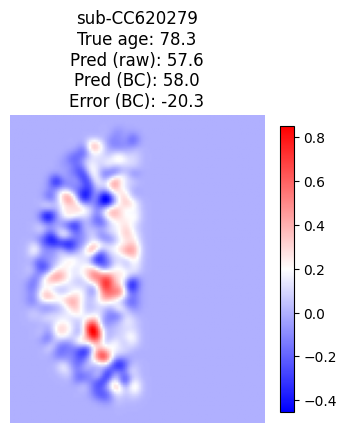

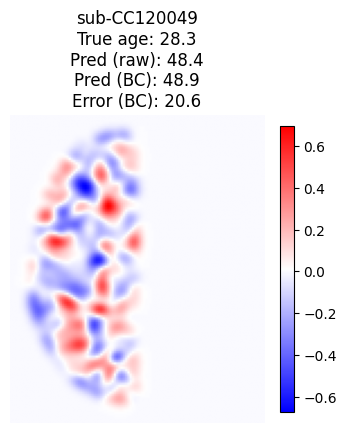

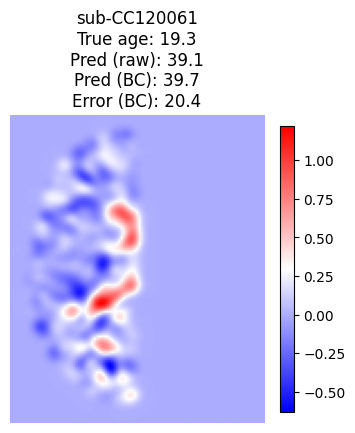

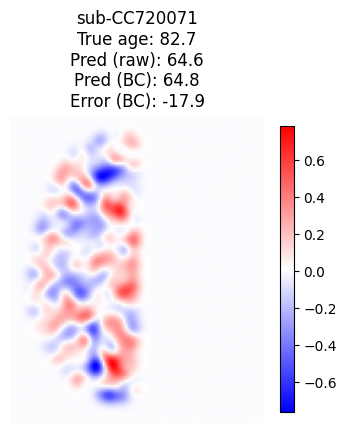

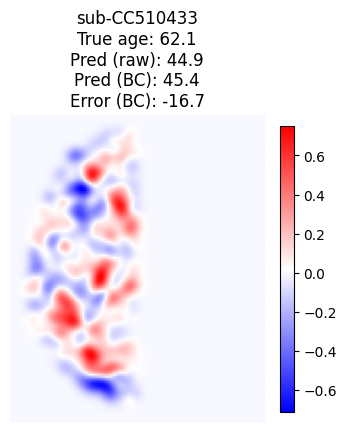

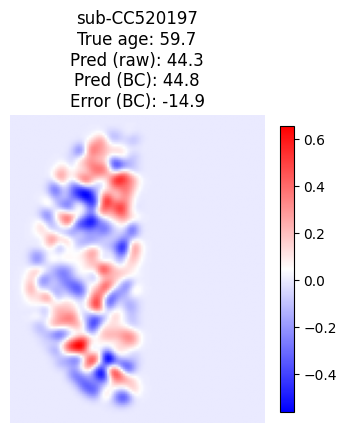

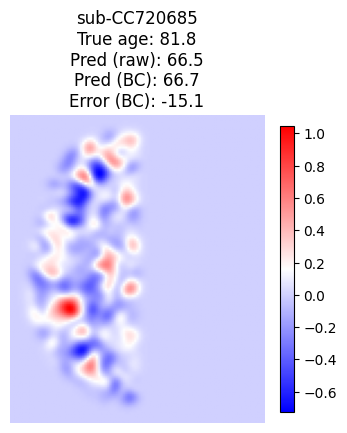

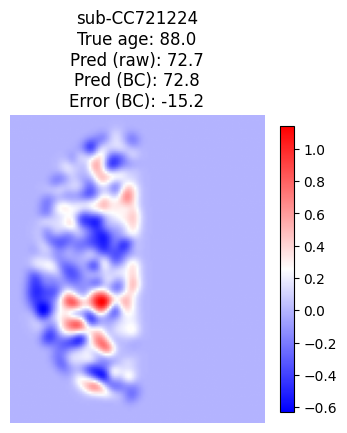

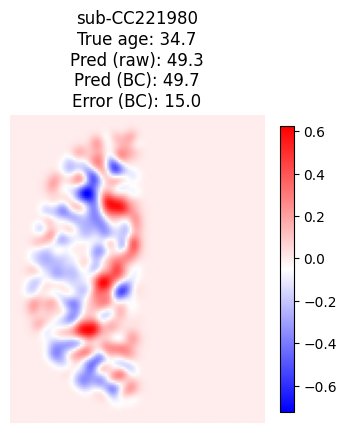

In [74]:
# Worst cases sorted after raw predictions
for _, row in worst_cases.iterrows():
    title = (
    f"{row['participant_id']}\n"
    f"True age: {row['age']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"Error (BC): {row['error_bc']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

## Plot: True age vs Predicted age

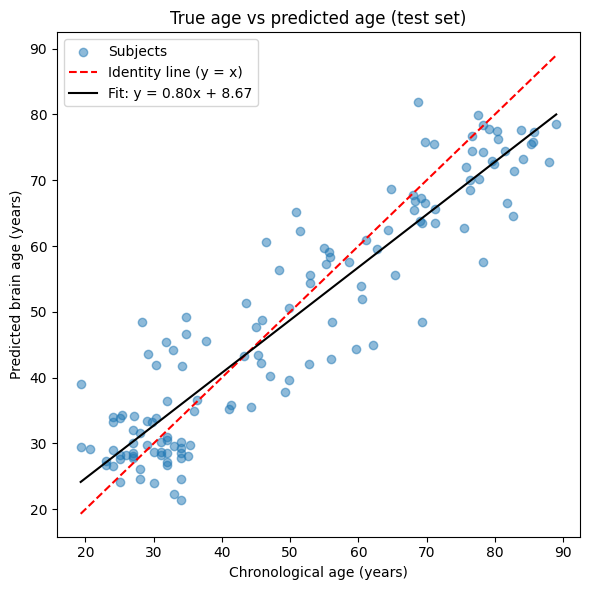

In [75]:
# Plot predicted brain age against chronological age for the raw test-set predictions
plt.figure(figsize=(6, 6))
plt.scatter(targs_test, preds_test, alpha=0.5, label="Subjects")
plt.plot(x_line, x_line, 'r--', label="Identity line (y = x)") # Identity line: perfect prediction

# Fit a linear regression line to summarize the relation between predicted and chronological age
coef_age = np.polyfit(targs_test, preds_test, 1)
y_fit = coef_age[0] * x_line + coef_age[1]
plt.plot(x_line, y_fit, 'k-', label=f"Fit: y = {coef_age[0]:.2f}x + {coef_age[1]:.2f}")

plt.xlabel("Chronological age (years)")
plt.ylabel("Predicted brain age (years)")
plt.title("True age vs predicted age (test set)")
plt.legend()
plt.tight_layout()
plt.show()

## Plot: True age vs Predicted age (Bias-corrected)

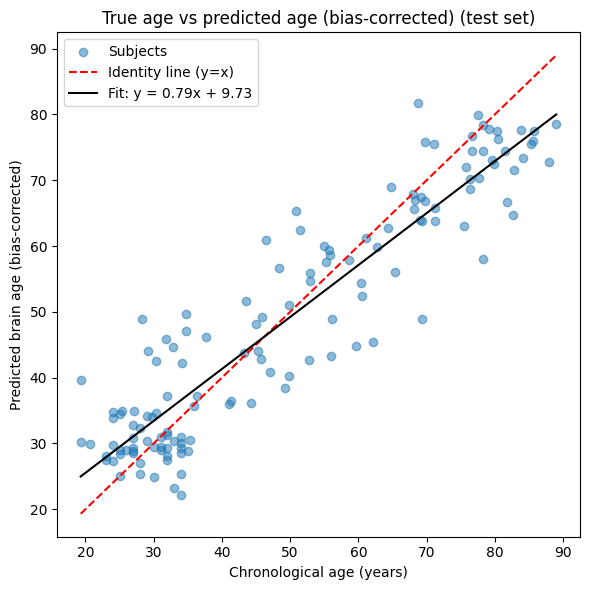

In [76]:
# Plot predicted brain age against chronological age after linear bias correction
coef_age_bc = np.polyfit(targs_test, preds_test_bc, 1)

plt.figure(figsize=(6, 6))
plt.scatter(targs_test, preds_test_bc, alpha=0.5, label="Subjects")
plt.plot(x_line, x_line, 'r--', label="Identity line (y=x)")
plt.plot(x_line, coef_age_bc[0]*x_line + coef_age_bc[1], 'k-', 
         label=f"Fit: y = {coef_age_bc[0]:.2f}x + {coef_age_bc[1]:.2f}")

plt.xlabel("Chronological age (years)")
plt.ylabel("Predicted brain age (bias-corrected)")
plt.title("True age vs predicted age (bias-corrected) (test set)")
plt.legend()
plt.tight_layout()
plt.show()